# Actividad
## Variaciones en Heston


Simulando con xi = 0.1...


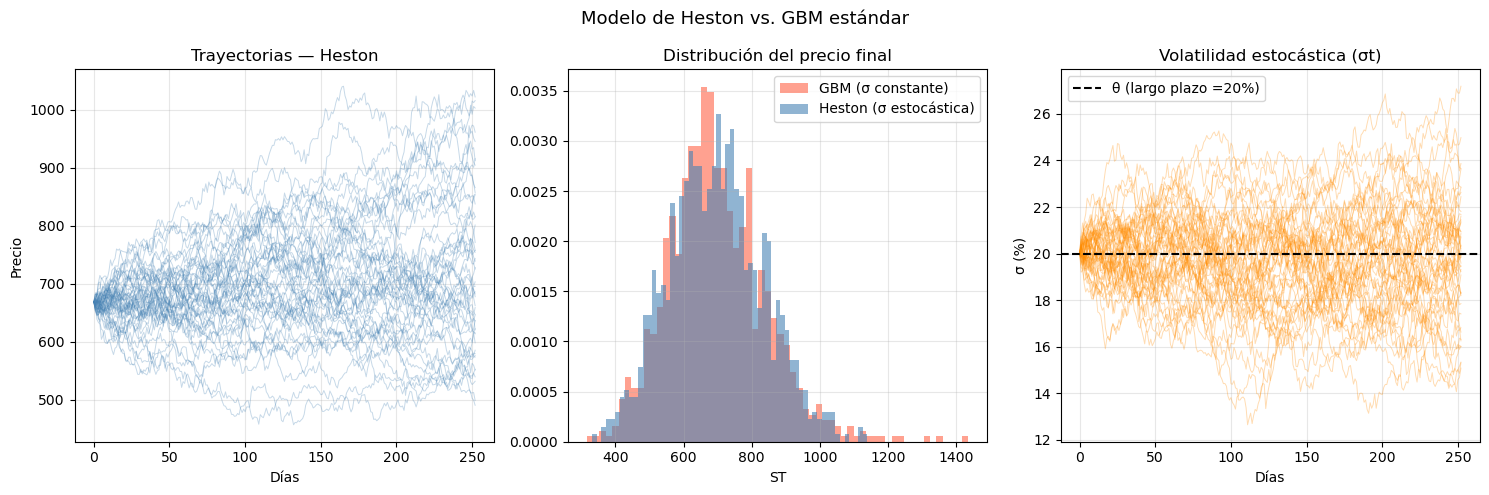


Simulando con xi = 0.4...


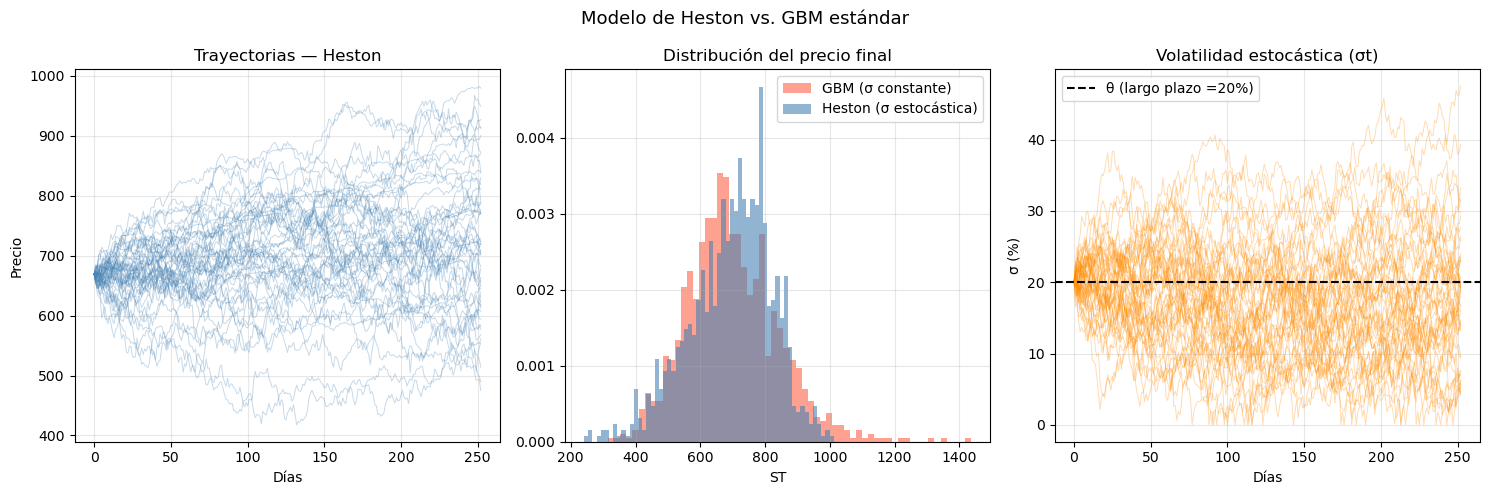


Simulando con xi = 0.9...


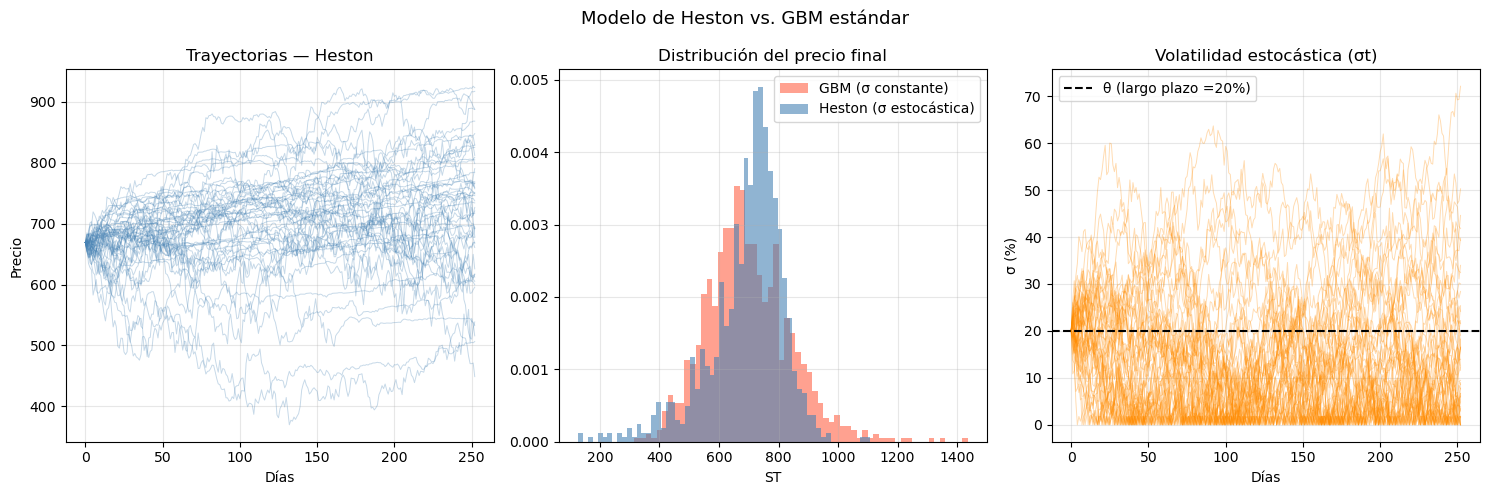

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = [0.1, 0.4, 0.9]
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

for xi_i in xi:
    print(f"\nSimulando con xi = {xi_i:.1f}...")
    S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi_i, rho, T, N, M)

    # --- Comparación: GBM estándar vs. Heston ---
    sigma_const = 0.20
    dt = T / N
    Z  = np.random.randn(M, N)
    S_gbm = np.zeros((M, N + 1))
    S_gbm[:, 0] = S0
    for t in range(1, N + 1):
        S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
            (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
        )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Trayectorias
    for i in range(50):
        axes[0].plot(S_heston[i], alpha=0.3, linewidth=0.7, color='steelblue')
    axes[0].set_title('Trayectorias — Heston')
    axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Precio')
    axes[0].grid(True, alpha=0.3)

    # Distribución final: GBM vs Heston
    axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
                color='tomato',    label='GBM (σ constante)')
    axes[1].hist(S_heston[:, -1], bins=60, density=True, alpha=0.6,
                color='steelblue', label='Heston (σ estocástica)')
    axes[1].set_title('Distribución del precio final')
    axes[1].set_xlabel('ST')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Evolución de la varianza
    for i in range(50):
        axes[2].plot(np.sqrt(v_heston[i]) * 100, alpha=0.3,
                    linewidth=0.7, color='darkorange')
    axes[2].axhline(np.sqrt(theta) * 100, color='black',
                    linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
    axes[2].set_title('Volatilidad estocástica (σt)')
    axes[2].set_xlabel('Días')
    axes[2].set_ylabel('σ (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Modelo de Heston vs. GBM estándar', fontsize=13)
    plt.tight_layout()
    plt.show()


Simulando con λ = 1 saltos/año...


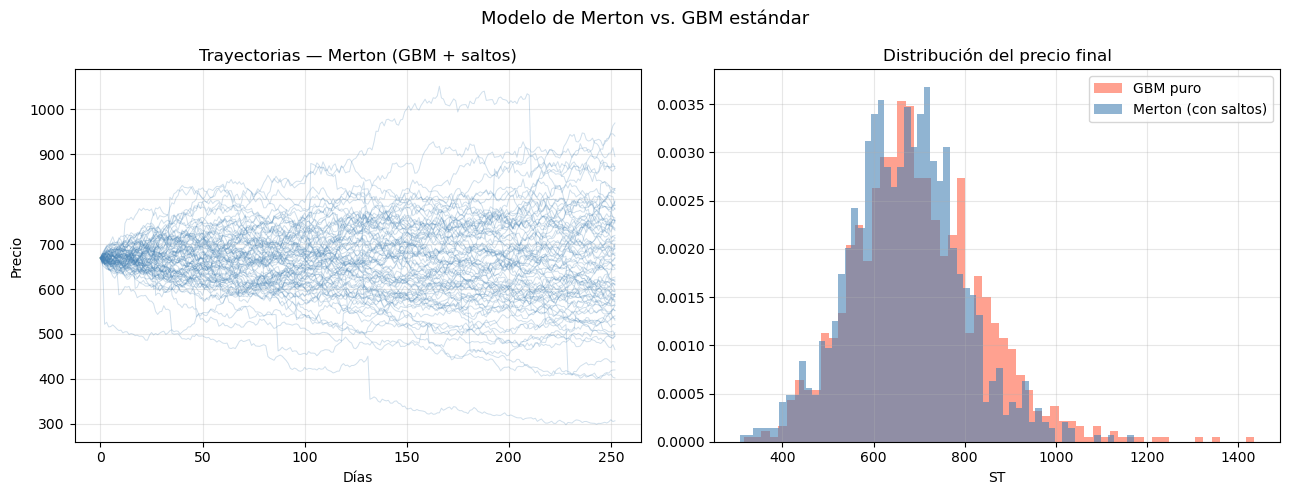


Simulando con λ = 4 saltos/año...


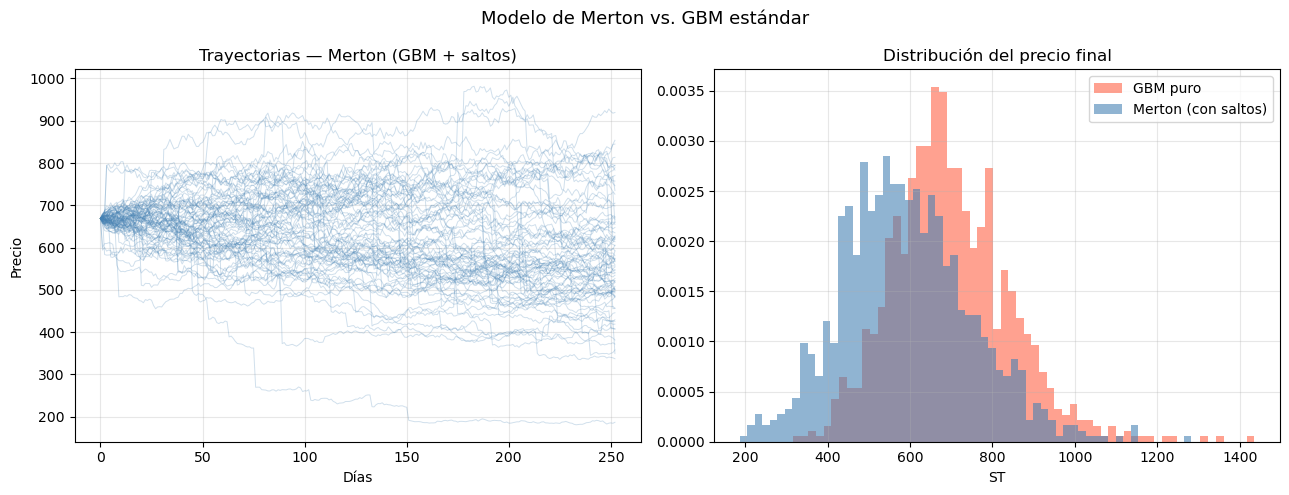


Simulando con λ = 15 saltos/año...


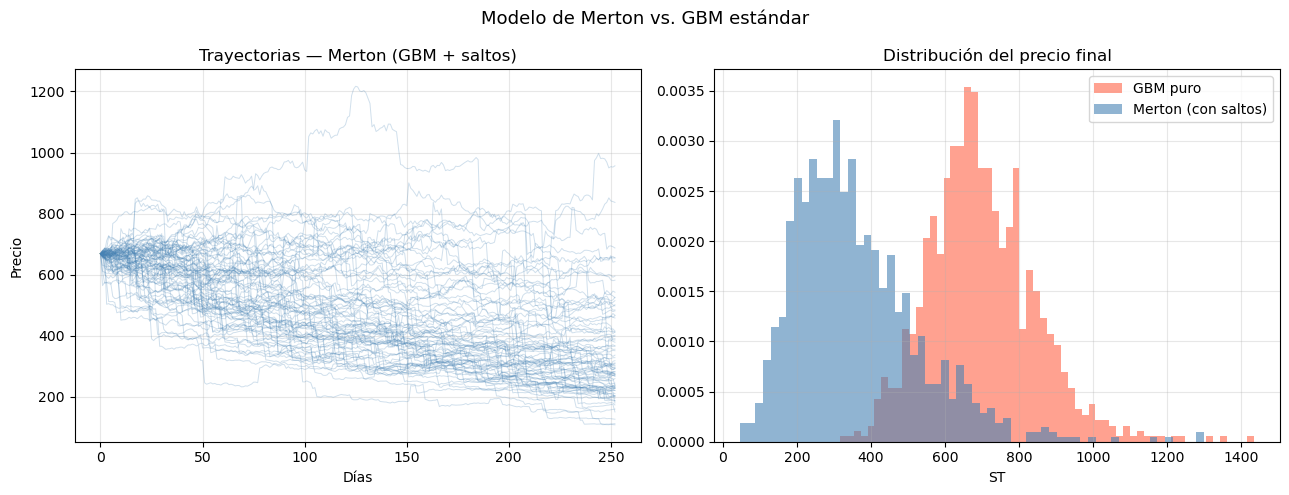

In [7]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)          # número de saltos en dt
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam     = [1, 4, 15]
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

for lam_i in lam:
    print(f"\nSimulando con λ = {lam_i} saltos/año...")
    S_merton = simular_merton(S0, mu, sigma, lam_i, mu_j, sigma_j, T, N, M)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Trayectorias — algunos saltos visibles
    for i in range(80):
        axes[0].plot(S_merton[i], alpha=0.25, linewidth=0.7, color='steelblue')
    axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
    axes[0].set_xlabel('Días')
    axes[0].set_ylabel('Precio')
    axes[0].grid(True, alpha=0.3)

    # Comparación distribución final
    axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
                color='tomato',    label='GBM puro')
    axes[1].hist(S_merton[:, -1], bins=60, density=True, alpha=0.6,
                color='steelblue', label='Merton (con saltos)')
    axes[1].set_title('Distribución del precio final')
    axes[1].set_xlabel('ST')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Modelo de Merton vs. GBM estándar', fontsize=13)
    plt.tight_layout()
    plt.show()

- **En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?**

El precio tiende a ser mayor. Supongo que eso tiene sentdo porque a mayor volatilidad, mayor rendimiento. Sin embargo la cola izquierda se vuelve más pesada (mayor probabilidad de incluso mayores pérdidas). 
- **En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?**

La distribución tiene sesgo a la izquierda y se apachurra. Creo que se debe a que, en la distribución de la volatilidad, hay muchos más saltos (más riesgo en el riesgo), entonces los precios caen más
- **Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM, sobreestimado o subestimado? ¿Por qué?**

Estaría subestimado. Black-Scholes asume una distribución normal, sin embargo la distribución en realidad siempre es leptocúrtica (colas grandes). BS asumiría súper improbable que caiga el precio machín cuando no es tan improbable como lo cree.
- **Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?**

Los saltos no son predecibles. No se puede predecir con certeza la volatilidad de la volatilidad (Entonces tendríamos que sacar la volatilidad de la volatilidad de la volatilidad lol, obviamente no). La limitación es que asume cierto comportamiento constante de la volatilidad.
- **¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?**

Es más fácil sacar la volatilidad implícita de BS